# Milestone 02: Air Quality and Asthma Analysis

**Research Question:** Is there a relationship between county-level PM2.5 air pollution and adult asthma prevalence in the United States?

This notebook retrieves data from public web sources, cleans and merges the datasets using county FIPS codes, conducts exploratory analysis, and creates visualizations. The analysis is exploratory and is not intended to prove causation.

## 1. Import Packages and Set Up Folders

This section imports the Python packages used for the project and creates folders for saved data and visualizations.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Create folders for saved outputs
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (9, 6)

## 2. Load CDC PLACES Asthma Data

The CDC PLACES dataset includes county-level estimates for health outcomes. I use the current asthma measure for adults and keep the most recent year available in the dataset.

In [28]:
CDC_PLACES_URL = "https://data.cdc.gov/resource/swc5-untb.csv?$limit=500000"

places_raw = pd.read_csv(CDC_PLACES_URL)

# Standardize column names to make the code easier to write
places_raw.columns = places_raw.columns.str.lower().str.replace(" ", "_")

print(places_raw.shape)
places_raw.head()

(229298, 22)


C:\Users\Chase\AppData\Local\Temp\ipykernel_12256\3486142563.py:3: DtypeWarning: Columns (0: data_value_footnote_symbol, 1: data_value_footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  places_raw = pd.read_csv(CDC_PLACES_URL)


,year,stateabbr,statedesc,locationname,datasource,category,measure,data_value_unit,data_value_type,data_value,data_value_footnote_symbol,data_value_footnote,low_confidence_limit,high_confidence_limit,totalpopulation,totalpop18plus,locationid,categoryid,measureid,datavaluetypeid,short_question_text,geolocation
0,2023,AR,Arkansas,Drew,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,29.9,NaN,NaN,26.6,33.3,16945,13230,5043,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-91.7196579038053 33.5894113647675)
1,2023,AR,Arkansas,Fulton,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,10.6,NaN,NaN,9.2,11.9,12421,9795,5049,HLTHOUT,CASTHMA,CrdPrv,Current Asthma,POINT (-91.817888079321 36.3816206347765)
2,2023,AR,Arkansas,Howard,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,31.2,NaN,NaN,27.7,34.8,12533,9311,5061,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-93.9938053308515 34.0889044688856)
3,2023,AR,Arkansas,Miller,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,4.7,NaN,NaN,4.2,5.3,42415,32396,5091,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-93.8924281761086 33.3123156126392)
4,2023,AR,Arkansas,Ouachita,BRFSS,Disability,Any disability among adults,%,Crude prevalence,42.8,NaN,NaN,37.9,47.8,21793,16948,5103,DISABLT,DISABILITY,CrdPrv,Any Disability,POINT (-92.882040791321 33.593253927504)


In [29]:
# Check available columns
places_raw.columns.tolist()

['year',
 'stateabbr',
 'statedesc',
 'locationname',
 'datasource',
 'category',
 'measure',
 'data_value_unit',
 'data_value_type',
 'data_value',
 'data_value_footnote_symbol',
 'data_value_footnote',
 'low_confidence_limit',
 'high_confidence_limit',
 'totalpopulation',
 'totalpop18plus',
 'locationid',
 'categoryid',
 'measureid',
 'datavaluetypeid',
 'short_question_text',
 'geolocation']

In [30]:
# Filter to current asthma.
# CDC PLACES commonly uses measureid CASTHMA for current asthma.
# The backup text filter makes the code more robust if the dataset changes slightly.
if "measureid" in places_raw.columns:
    asthma = places_raw[places_raw["measureid"].astype(str).str.upper().eq("CASTHMA")].copy()
else:
    asthma = places_raw[places_raw["measure"].astype(str).str.contains("current asthma", case=False, na=False)].copy()

# If both crude and age-adjusted estimates are present, prefer age-adjusted prevalence.
if "data_value_type" in asthma.columns:
    age_adjusted = asthma[asthma["data_value_type"].astype(str).str.contains("age-adjusted", case=False, na=False)].copy()
    if len(age_adjusted) > 0:
        asthma = age_adjusted

# Keep the most recent year available
if "year" in asthma.columns:
    asthma["year"] = pd.to_numeric(asthma["year"], errors="coerce")
    latest_year = int(asthma["year"].max())
    asthma = asthma[asthma["year"] == latest_year].copy()
    print(f"Using CDC PLACES asthma year: {latest_year}")

# Create clean FIPS code
asthma["fips"] = asthma["locationid"].astype(str).str.zfill(5)

# Convert asthma value to numeric
asthma["asthma_prevalence_pct"] = pd.to_numeric(asthma["data_value"], errors="coerce")

# Select useful columns
keep_cols = [
    "fips", "stateabbr", "statedesc", "locationname", "measure",
    "data_value_type", "asthma_prevalence_pct"
]
keep_cols = [col for col in keep_cols if col in asthma.columns]

asthma_clean = asthma[keep_cols].dropna(subset=["asthma_prevalence_pct"]).drop_duplicates(subset=["fips"])

asthma_clean.to_csv(DATA_DIR / "cdc_asthma_county_clean.csv", index=False)

print(asthma_clean.shape)
asthma_clean.head()

Using CDC PLACES asthma year: 2023
(2957, 7)


,fips,stateabbr,statedesc,locationname,measure,data_value_type,asthma_prevalence_pct
269,02220,AK,Alaska,Sitka,Current asthma among adults,Age-adjusted prevalence,10.1
296,05109,AR,Arkansas,Pike,Current asthma among adults,Age-adjusted prevalence,10.3
363,01075,AL,Alabama,Lamar,Current asthma among adults,Age-adjusted prevalence,10.5
378,06025,CA,California,Imperial,Current asthma among adults,Age-adjusted prevalence,9.2
531,01007,AL,Alabama,Bibb,Current asthma among adults,Age-adjusted prevalence,10.4


## 3. Load EPA PM2.5 Air Quality Data

The EPA annual concentration file is monitor-level. I filter it to PM2.5 FRM/FEM Mass using EPA parameter code `88101`, then aggregate monitor readings to the county level.

In [31]:
import zipfile
import requests
from io import BytesIO

EPA_PM25_URL = "https://aqs.epa.gov/aqsweb/airdata/annual_conc_by_monitor_2023.zip"

# Download the ZIP file
response = requests.get(EPA_PM25_URL)
response.raise_for_status()

# Open the ZIP file from memory
with zipfile.ZipFile(BytesIO(response.content)) as z:
    # Find the CSV file inside the ZIP
    csv_file = [file for file in z.namelist() if file.endswith(".csv")][0]
    
    # Read the CSV file into pandas
    with z.open(csv_file) as f:
        epa_raw = pd.read_csv(f)

# Clean column names
epa_raw.columns = epa_raw.columns.str.lower().str.replace(" ", "_")

print(epa_raw.shape)
epa_raw.head()

(82378, 55)


,state_code,county_code,site_num,parameter_code,poc,latitude,longitude,datum,parameter_name,sample_duration,pollutant_standard,metric_used,method_name,year,units_of_measure,event_type,observation_count,observation_percent,completeness_indicator,valid_day_count,required_day_count,exceptional_data_count,null_data_count,primary_exceedance_count,secondary_exceedance_count,certification_indicator,num_obs_below_mdl,arithmetic_mean,arithmetic_standard_dev,1st_max_value,1st_max_datetime,2nd_max_value,2nd_max_datetime,3rd_max_value,3rd_max_datetime,4th_max_value,4th_max_datetime,1st_max_non_overlapping_value,1st_no_max_datetime,2nd_max_non_overlapping_value,2nd_no_max_datetime,99th_percentile,98th_percentile,95th_percentile,90th_percentile,75th_percentile,50th_percentile,10th_percentile,local_site_name,address,state_name,county_name,city_name,cbsa_name,date_of_last_change
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,1 HOUR,Ozone 1-hour 1979,Daily maxima of observed hourly values (betwee...,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,2023,Parts per million,No Events,5148,92,Y,225,245,0,732,0.0,0.0,Certified,0,0.047836,0.011096,0.078,5/3/2023 13:00,0.077,6/9/2023 12:00,0.069,6/10/2023 11:00,0.069,9/9/2023 16:00,NaN,NaN,NaN,NaN,0.069,0.068,0.065,0.062,0.055,0.049,0.033,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",5/24/2024
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,Ozone 8-Hour 1997,Daily maximum of 8 hour running average of obs...,NaN,2023,Parts per million,No Events,5345,91,Y,222,245,0,0,0.0,0.0,Certified,0,0.043288,0.010427,0.067,5/3/2023 11:00,0.067,6/9/2023 11:00,0.067,6/10/2023 11:00,0.065,8/18/2023 10:00,NaN,NaN,NaN,NaN,0.067,0.062,0.059,0.056,0.051,0.044,0.028,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",5/24/2024
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,Ozone 8-Hour 2008,Daily maximum of 8 hour running average of obs...,NaN,2023,Parts per million,No Events,5345,91,Y,222,245,0,0,0.0,0.0,Certified,0,0.043288,0.010427,0.067,5/3/2023 11:00,0.067,6/9/2023 11:00,0.067,6/10/2023 11:00,0.065,8/18/2023 10:00,NaN,NaN,NaN,NaN,0.067,0.062,0.059,0.056,0.051,0.044,0.028,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",5/24/2024
3,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,Ozone 8-hour 2015,Daily maximum of 8-hour running average,NaN,2023,Parts per million,No Events,3789,88,Y,216,245,0,0,0.0,0.0,Certified,0,0.043255,0.010435,0.067,5/3/2023 11:00,0.067,6/9/2023 11:00,0.067,6/10/2023 11:00,0.065,8/18/2023 10:00,NaN,NaN,NaN,NaN,0.067,0.062,0.059,0.056,0.051,0.045,0.028,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",5/24/2024
4,1,3,10,88101,3,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,1 HOUR,NaN,Observed Values,Met One BAM-1022 Mass Monitor w/ VSCC or TE-PM...,2023,Micrograms/cubic meter (LC),No Events,8150,93,Y,347,365,0,610,NaN,NaN,Certified,0,7.690417,8.271605,549.800,11/6/2023 8:00,121.700,8/22/2023 1:00,68.200,11/7/2023 7:00,57.500,12/13/2023 17:00,NaN,NaN,NaN,NaN,23.500,20.700,17.300,14.600,10.600,7.000,1.400,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",8/6/2024


In [32]:
# Check available columns
epa_raw.columns.tolist()

['state_code',
 'county_code',
 'site_num',
 'parameter_code',
 'poc',
 'latitude',
 'longitude',
 'datum',
 'parameter_name',
 'sample_duration',
 'pollutant_standard',
 'metric_used',
 'method_name',
 'year',
 'units_of_measure',
 'event_type',
 'observation_count',
 'observation_percent',
 'completeness_indicator',
 'valid_day_count',
 'required_day_count',
 'exceptional_data_count',
 'null_data_count',
 'primary_exceedance_count',
 'secondary_exceedance_count',
 'certification_indicator',
 'num_obs_below_mdl',
 'arithmetic_mean',
 'arithmetic_standard_dev',
 '1st_max_value',
 '1st_max_datetime',
 '2nd_max_value',
 '2nd_max_datetime',
 '3rd_max_value',
 '3rd_max_datetime',
 '4th_max_value',
 '4th_max_datetime',
 '1st_max_non_overlapping_value',
 '1st_no_max_datetime',
 '2nd_max_non_overlapping_value',
 '2nd_no_max_datetime',
 '99th_percentile',
 '98th_percentile',
 '95th_percentile',
 '90th_percentile',
 '75th_percentile',
 '50th_percentile',
 '10th_percentile',
 'local_site_name',


In [33]:
# Filter for PM2.5 FRM/FEM Mass.
# Parameter code 88101 is commonly used for regulatory PM2.5 FRM/FEM data.
epa_pm25 = epa_raw[epa_raw["parameter_code"].astype(str).eq("88101")].copy()

# Create county FIPS from state and county codes
epa_pm25["state_code"] = epa_pm25["state_code"].astype(str).str.zfill(2)
epa_pm25["county_code"] = epa_pm25["county_code"].astype(str).str.zfill(3)
epa_pm25["fips"] = epa_pm25["state_code"] + epa_pm25["county_code"]

# Convert relevant columns to numeric
epa_pm25["arithmetic_mean"] = pd.to_numeric(epa_pm25["arithmetic_mean"], errors="coerce")
epa_pm25["observation_count"] = pd.to_numeric(epa_pm25["observation_count"], errors="coerce")

# Drop missing or invalid values
epa_pm25 = epa_pm25.dropna(subset=["arithmetic_mean", "observation_count"])
epa_pm25 = epa_pm25[epa_pm25["observation_count"] > 0]

# Weighted average function for county-level PM2.5
def weighted_pm25(group):
    return np.average(group["arithmetic_mean"], weights=group["observation_count"])

# Aggregate monitor-level data to county-level data
pm25_county = (
    epa_pm25
    .groupby(["fips", "state_name", "county_name"], as_index=False)
    .apply(lambda g: pd.Series({
        "pm25_mean": weighted_pm25(g),
        "monitor_count": g["site_num"].nunique(),
        "total_observations": g["observation_count"].sum()
    }))
)

# Rename columns for easier use later
pm25_county = pm25_county.rename(columns={
    "state_name": "state",
    "county_name": "county"
})

# Save cleaned EPA county-level file
pm25_county.to_csv(DATA_DIR / "epa_pm25_county_clean.csv", index=False)

print(pm25_county.shape)
pm25_county.head()

(635, 6)


,fips,state,county,pm25_mean,monitor_count,total_observations
0,01003,Alabama,Baldwin,7.673528,1.0,10838.0
1,01027,Alabama,Clay,8.082885,1.0,10529.0
2,01049,Alabama,DeKalb,8.934707,1.0,11355.0
3,01055,Alabama,Etowah,9.838832,1.0,11063.0
4,01073,Alabama,Jefferson,10.059638,5.0,48892.0


## 4. Merge CDC and EPA Data

Both datasets use county-level FIPS codes, so the merge uses the five-digit `fips` field.

In [34]:
merged = asthma_clean.merge(pm25_county, on="fips", how="inner")

merged.to_csv(DATA_DIR / "merged_air_quality_asthma.csv", index=False)

print(merged.shape)
merged.head()

(578, 12)


,fips,stateabbr,statedesc,locationname,measure,data_value_type,asthma_prevalence_pct,state,county,pm25_mean,monitor_count,total_observations
0,06025,CA,California,Imperial,Current asthma among adults,Age-adjusted prevalence,9.2,California,Imperial,8.816319,3.0,31019.0
1,06007,CA,California,Butte,Current asthma among adults,Age-adjusted prevalence,10.5,California,Butte,7.913482,1.0,31376.0
2,04021,AZ,Arizona,Pinal,Current asthma among adults,Age-adjusted prevalence,10.9,Arizona,Pinal,6.849655,3.0,32567.0
3,06051,CA,California,Mono,Current asthma among adults,Age-adjusted prevalence,9.9,California,Mono,3.530301,2.0,33887.0
4,06065,CA,California,Riverside,Current asthma among adults,Age-adjusted prevalence,9.5,California,Riverside,9.307452,6.0,89998.0


## 5. Descriptive Statistics

This section summarizes the merged dataset and calculates a simple correlation between PM2.5 concentration and adult asthma prevalence.

In [35]:
merged[["asthma_prevalence_pct", "pm25_mean", "monitor_count", "total_observations"]].describe()

,asthma_prevalence_pct,pm25_mean,monitor_count,total_observations
count,578.000000,578.000000,578.000000,578.000000
mean,10.642388,8.215329,1.610727,31687.996540
std,1.012428,2.002273,1.511030,38168.611835
min,7.900000,2.290591,1.000000,362.000000
25%,10.000000,7.101757,1.000000,11190.500000
50%,10.600000,8.403314,1.000000,30444.000000
75%,11.300000,9.678294,2.000000,34610.000000
max,14.600000,14.692624,14.000000,503986.000000


In [36]:
correlation = merged["pm25_mean"].corr(merged["asthma_prevalence_pct"])
print(f"Correlation between PM2.5 and asthma prevalence: {correlation:.3f}")

Correlation between PM2.5 and asthma prevalence: -0.014


## 6. Visualization 1: PM2.5 vs. Asthma Prevalence

This scatter plot shows whether counties with higher PM2.5 levels tend to have higher adult asthma prevalence. A fitted trend line is included to make the overall direction easier to see.

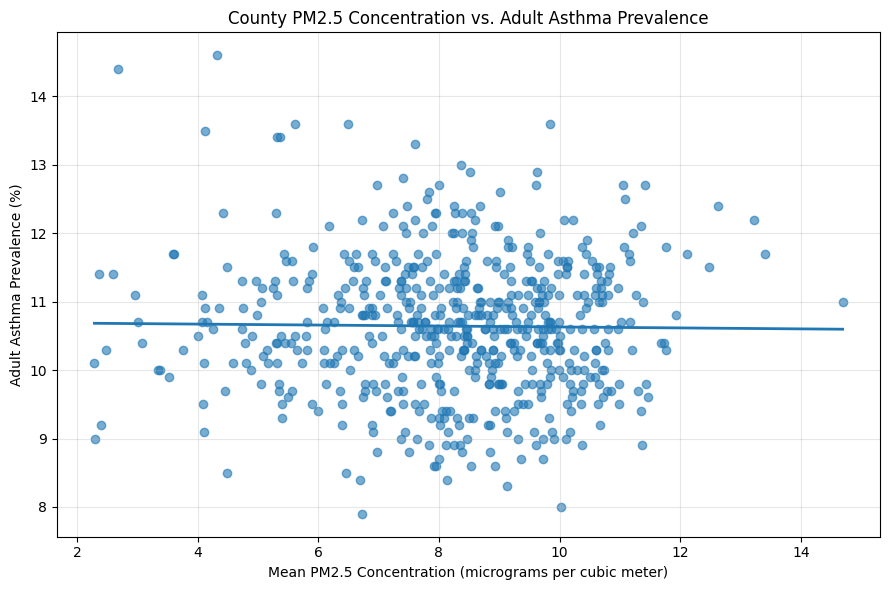

In [37]:
x = merged["pm25_mean"]
y = merged["asthma_prevalence_pct"]

plt.figure()
plt.scatter(x, y, alpha=0.6)

# Add trend line if enough data exists
if len(merged) > 2:
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, linewidth=2)

plt.title("County PM2.5 Concentration vs. Adult Asthma Prevalence")
plt.xlabel("Mean PM2.5 Concentration (micrograms per cubic meter)")
plt.ylabel("Adult Asthma Prevalence (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pm25_vs_asthma_scatter.png", dpi=300)
plt.show()

## 7. Visualization 2: Counties with Highest PM2.5 Levels

This bar chart shows the counties in the merged dataset with the highest average PM2.5 concentrations.

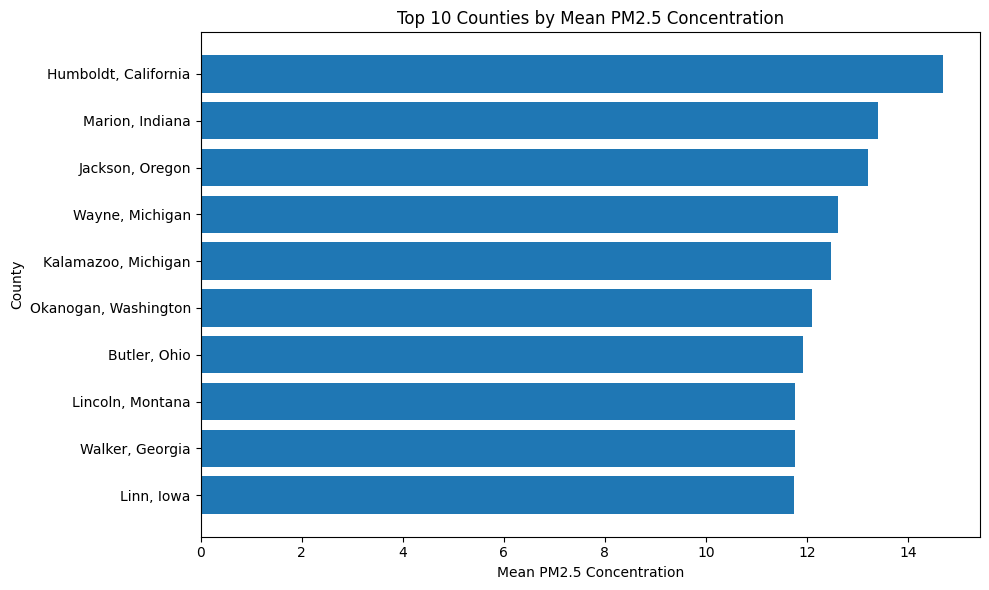

In [38]:
top_pm25 = merged.sort_values("pm25_mean", ascending=False).head(10).copy()
top_pm25["county_label"] = top_pm25["county"] + ", " + top_pm25["state"]

plt.figure(figsize=(10, 6))
plt.barh(top_pm25["county_label"], top_pm25["pm25_mean"])
plt.gca().invert_yaxis()
plt.title("Top 10 Counties by Mean PM2.5 Concentration")
plt.xlabel("Mean PM2.5 Concentration")
plt.ylabel("County")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_pm25_counties.png", dpi=300)
plt.show()

## 8. Visualization 3: State Average PM2.5

This chart aggregates the merged county data to the state level and shows the ten states with the highest average PM2.5 values among counties with available EPA monitor data.

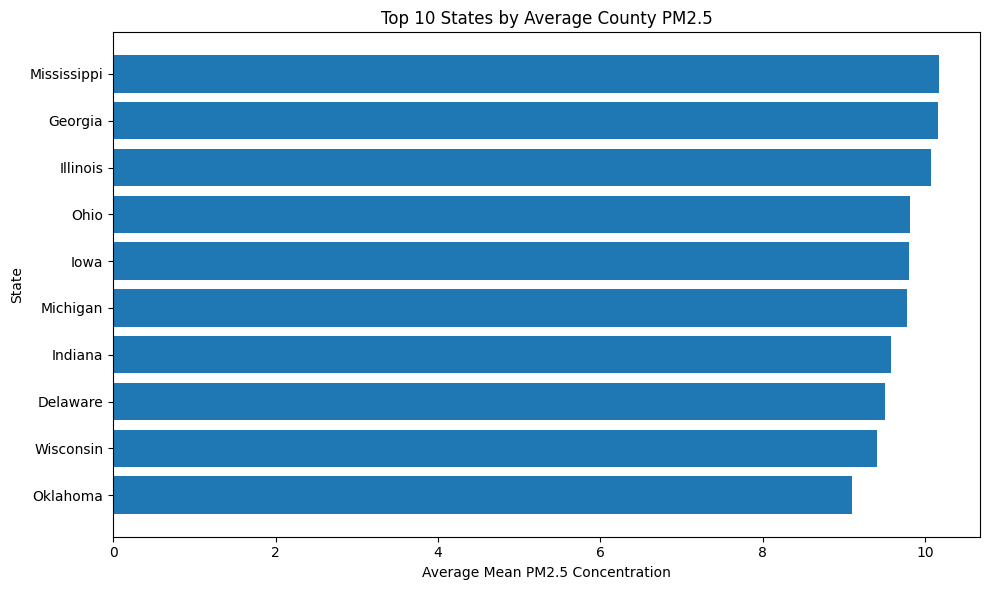

,state,avg_pm25,avg_asthma,counties_in_analysis
22,Mississippi,10.163815,10.000000,7
9,Georgia,10.148878,10.494444,18
12,Illinois,10.066657,10.282353,17
33,Ohio,9.812847,11.315000,20
14,Iowa,9.802256,10.207692,13
20,Michigan,9.777769,11.506250,16
13,Indiana,9.575505,11.256522,23
6,Delaware,9.497210,11.233333,3
46,Wisconsin,9.407783,10.963158,19
34,Oklahoma,9.100334,12.000000,12


In [39]:
state_avg = (
    merged
    .groupby("state", as_index=False)
    .agg(
        avg_pm25=("pm25_mean", "mean"),
        avg_asthma=("asthma_prevalence_pct", "mean"),
        counties_in_analysis=("fips", "count")
    )
    .sort_values("avg_pm25", ascending=False)
)

state_top10 = state_avg.head(10)

plt.figure(figsize=(10, 6))
plt.barh(state_top10["state"], state_top10["avg_pm25"])
plt.gca().invert_yaxis()
plt.title("Top 10 States by Average County PM2.5")
plt.xlabel("Average Mean PM2.5 Concentration")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "state_average_pm25.png", dpi=300)
plt.show()

state_avg.head(10)

## 9. Interpretation

The scatter plot compares county-level mean PM2.5 concentration with adult asthma prevalence. Based on the visualization, there does not appear to be a strong relationship between these two variables in the merged dataset. The points are widely scattered, and the fitted trend line is nearly flat. This suggests that counties with higher average PM2.5 levels do not consistently have higher adult asthma prevalence in this analysis. In other words, PM2.5 may still matter for respiratory health, but this simple county-level comparison does not show a clear positive association.

Most counties in the scatter plot are clustered between roughly 7 and 11 micrograms per cubic meter of PM2.5 and between about 9% and 12% adult asthma prevalence. There are also several outliers. Some counties have relatively high asthma prevalence despite low PM2.5 levels, while others have higher PM2.5 levels but only average asthma prevalence. This pattern suggests that asthma prevalence is likely shaped by a combination of factors beyond annual PM2.5 concentration alone.

The state-level bar chart shows that average county PM2.5 concentration varies across states. Mississippi, Georgia, Illinois, Ohio, Iowa, Michigan, Indiana, Delaware, Wisconsin, and Oklahoma appear among the highest states in this dataset. This does not necessarily mean that every county in those states has poor air quality, but it does show that the counties included in the EPA monitoring data for those states tend to have higher average PM2.5 levels. Because EPA monitor coverage is not evenly distributed across every county, these state averages should be interpreted as averages of counties with available monitor data rather than a perfect statewide measure.

The county-level bar chart provides a more detailed look at where PM2.5 concentrations are highest. Humboldt County, California has the highest mean PM2.5 concentration in this dataset, followed by counties such as Marion County, Indiana; Jackson County, Oregon; Wayne County, Michigan; and Kalamazoo County, Michigan. These counties may have higher values because of local pollution sources, geography, wildfire smoke, industrial activity, transportation patterns, or other environmental factors. However, this analysis does not identify the specific cause of high PM2.5 in each county.

Overall, the results suggest that PM2.5 concentration alone does not explain county-level adult asthma prevalence very well. Asthma is a complex health outcome that can be influenced by many additional factors, including smoking rates, poverty, housing quality, occupational exposure, indoor air pollution, health care access, race and ethnicity, climate, pollen, and other pollutants such as ozone or nitrogen dioxide. Because this project only compares one air quality measure with one health outcome, the findings should be interpreted as exploratory rather than causal.

A key limitation is that the EPA PM2.5 data is based on air quality monitors, and not every U.S. county has a monitor. This means the merged dataset only includes counties that appear in both the CDC asthma dataset and the EPA monitor dataset. Another limitation is that the asthma data is county-level and age-adjusted, so it does not capture individual-level exposure or differences within counties. Also, annual average PM2.5 may not capture short-term spikes in pollution that could affect asthma symptoms or emergency visits.

Even though the relationship is not strong in the scatter plot, I feel this was a successful project utilizing the code I learned throughout the semester.

In [40]:
print("Final project files created:")
print("- data/cdc_asthma_county_clean.csv")
print("- data/epa_pm25_county_clean.csv")
print("- data/merged_air_quality_asthma.csv")
print("- outputs/pm25_vs_asthma_scatter.png")
print("- outputs/top_pm25_counties.png")
print("- outputs/state_average_pm25.png")

Final project files created:
- data/cdc_asthma_county_clean.csv
- data/epa_pm25_county_clean.csv
- data/merged_air_quality_asthma.csv
- outputs/pm25_vs_asthma_scatter.png
- outputs/top_pm25_counties.png
- outputs/state_average_pm25.png
